In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing the datastet

df = pd.read_csv('netflix.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Checking the data type of the columns present in the dataset

df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [5]:
#Checking the 
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Now we can see that the following columns have higher number of null values.

- Director
- Cast
- Country

In [6]:
# checking the percent of data missing in the columns

df.isnull().mean()*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

The percentage of null values for the director column is on the higher side, hence we cannot drop the null values from the Directors table

In [7]:
# Fixing the null values from the Directors column

df.director.value_counts().sort_values(ascending = False)

director
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Suhas Kadav                 16
Jay Karas                   14
                            ..
Austin Stark                 1
Kristian Levring             1
Ajay Bhuyan, Kunal Kohli     1
Karan Lalit Butani           1
Mozez Singh                  1
Name: count, Length: 4528, dtype: int64

In [8]:
# Replace missing director with "Unknown"
df['director'] = df['director'].fillna("Unknown")

In [9]:
df.director.value_counts().sort_values(ascending = False)

director
Unknown                     2634
Rajiv Chilaka                 19
Raúl Campos, Jan Suter        18
Suhas Kadav                   16
Marcus Raboy                  16
                            ... 
Bruce Robinson                 1
Austin Stark                   1
Kristian Levring               1
Ajay Bhuyan, Kunal Kohli       1
Mozez Singh                    1
Name: count, Length: 4529, dtype: int64

In [10]:
# Also filling the NaN values in the columns : Cast and Country

df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

In [11]:
#Checking for values in the columns now 

df.country.value_counts(ascending= True)

country
Chile, Argentina                 1
Canada, Japan, Netherlands       1
United States, Hungary           1
France, Germany                  1
France, Qatar                    1
                              ... 
Japan                          245
United Kingdom                 419
Unknown                        831
India                          972
United States                 2818
Name: count, Length: 749, dtype: int64

Okay now if we see we can see that there are also countries such as (*Chile,Argentina*),(*Canada, Japan, Netherlands*) against one entry. This needs to be fixed

In [12]:
# Fixing the country column by using the explode function

df.explode?

Signature: df.explode(column: 'IndexLabel', ignore_index: 'bool' = False) -> 'DataFrame'
Docstring:
Transform each element of a list-like to a row, replicating index values.

Parameters
----------
column : IndexLabel
    Column(s) to explode.
    For multiple columns, specify a non-empty list with each element
    be str or tuple, and all specified columns their list-like data
    on same row of the frame must have matching length.

    .. versionadded:: 1.3.0
        Multi-column explode

ignore_index : bool, default False
    If True, the resulting index will be labeled 0, 1, …, n - 1.

Returns
-------
DataFrame
    Exploded lists to rows of the subset columns;
    index will be duplicated for these rows.

Raises
------
ValueError :
    * If columns of the frame are not unique.
    * If specified columns to explode is empty list.
    * If specified columns to explode have not matching count of
      elements rowwise in the frame.

See Also
--------
DataFrame.unstack : Pivot a level o

In [13]:
df['country'] = df['country'].str.split(",")
df_country = df.explode("country")

In [14]:
df_country

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [15]:
df_country.country.value_counts()

country
United States     3211
India             1008
Unknown            831
United Kingdom     628
 United States     479
                  ... 
 Ecuador             1
Iran                 1
Cyprus               1
 Mongolia            1
 Montenegro          1
Name: count, Length: 198, dtype: int64

In [16]:
# Checking the distribution of the type in the data set

df_country.type.value_counts().index

Index(['Movie', 'TV Show'], dtype='object', name='type')

In [17]:
# Creating a pie chart to understand the visual 


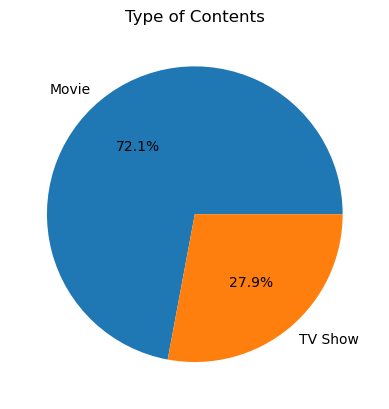

<Figure size 300x300 with 0 Axes>

In [18]:
plt.pie(df_country.type.value_counts(),labels=df_country.type.value_counts().index, autopct='%1.1f%%')
plt.title('Type of Contents')
plt.figure(figsize= (3,3))
plt.show()

In [19]:
#Creating dataframe for movies only
movies_df = df_country[df_country['type'] == 'Movie']

In [20]:
movies_df.reset_index(drop=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
2,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
3,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Ghana,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
4,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Burkina Faso,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
...,...,...,...,...,...,...,...,...,...,...,...,...
7814,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...",Jordan,"March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
7815,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
7816,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
7817,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [21]:
# Creating dataframe for Tv show only 

tvshow_df = df_country[df_country['type'] == 'TV Show']
tvshow_df.reset_index(drop=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
2,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
3,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
4,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
3026,s8798,TV Show,Zak Storm,Unknown,"Michael Johnston, Jessica Gee-George, Christin...",France,"September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
3027,s8798,TV Show,Zak Storm,Unknown,"Michael Johnston, Jessica Gee-George, Christin...",South Korea,"September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
3028,s8798,TV Show,Zak Storm,Unknown,"Michael Johnston, Jessica Gee-George, Christin...",Indonesia,"September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
3029,s8801,TV Show,Zindagi Gulzar Hai,Unknown,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [22]:
# Checking for the year in which most number of movies and TV shows were released

movies_df['release_year'].value_counts().head(5)

release_year
2017    974
2018    965
2016    878
2019    763
2020    565
Name: count, dtype: int64

In [23]:
# Similarly checking for the year which most number of tv shows were released

tvshow_df.release_year.value_counts().head(5)

release_year
2020    490
2019    445
2018    427
2021    345
2017    302
Name: count, dtype: int64

- Here we can see a trend that the years where the number of movies released was higher the number of TV shows released was lower.

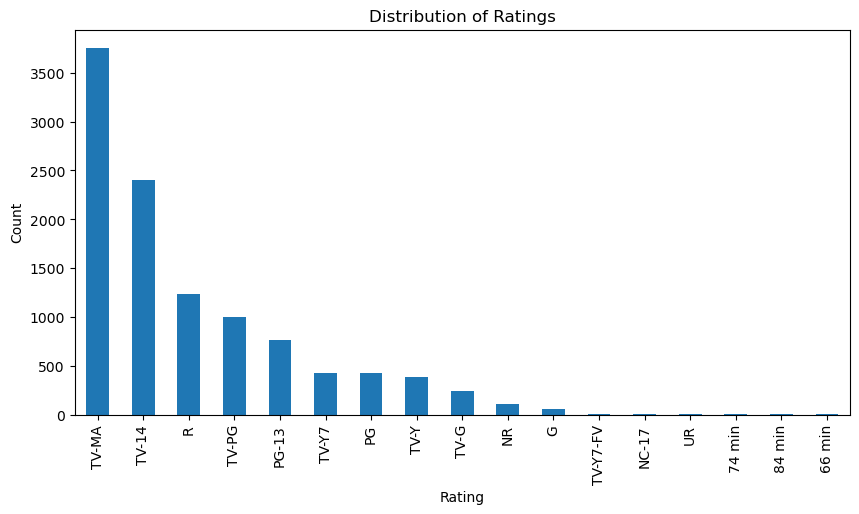

In [24]:
# Distribution of Rating 

plt.figure(figsize=(10,5))
df_country['rating'].value_counts().plot(kind='bar')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

- The most content on the platform is released under the **TV-MA** rating. This means that Netflix focuses more on Adult content.
- There is also very limited content for children. This indicates that there is an opportunity for Netflix to grow in **Family Friendly** segment
- We can also see that the Movie ratings such as **R** and **PG** also appear to have less content which indicates that Netflix library has more number of TV Shows than Movies.

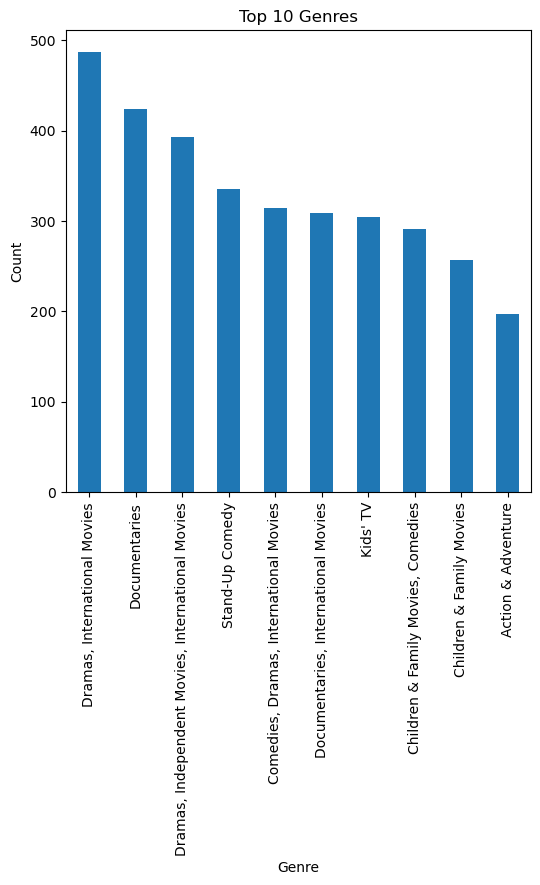

In [25]:
# Genre Type analysis

plt.figure(figsize=(6,6))
df_country['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

- The International Movies having a higher count means that Netflix is focusing more on global content rather than being hollywood centric.
- Netflix also has a higher number of movies in the documentaries genre showing the companys growing investment in the same.
- Netflix is also focusing on Stand Up Comedy genre which involves low production cost but it attracts more audience

In [26]:
# BiVariate analysis

# Q1. What type of content is available in different countries?

# Creating a dataframe which will store the country wise content distribution

country_content = df_country.groupby(['country','type']).size().unstack(fill_value= 0).sort_values(by= 'Movie',ascending= False)

In [27]:
country_content

type,Movie,TV Show
country,,
United States,2364,847
India,927,81
Unknown,440,391
United States,388,91
United Kingdom,382,246
...,...,...
Belarus,0,1
Luxembourg,0,1
Kuwait,0,1


In [28]:
# Having only the top 20 countries for better analysis

country_content = country_content.head(20)

In [29]:
country_content.shape

(20, 2)

<Axes: xlabel='country'>

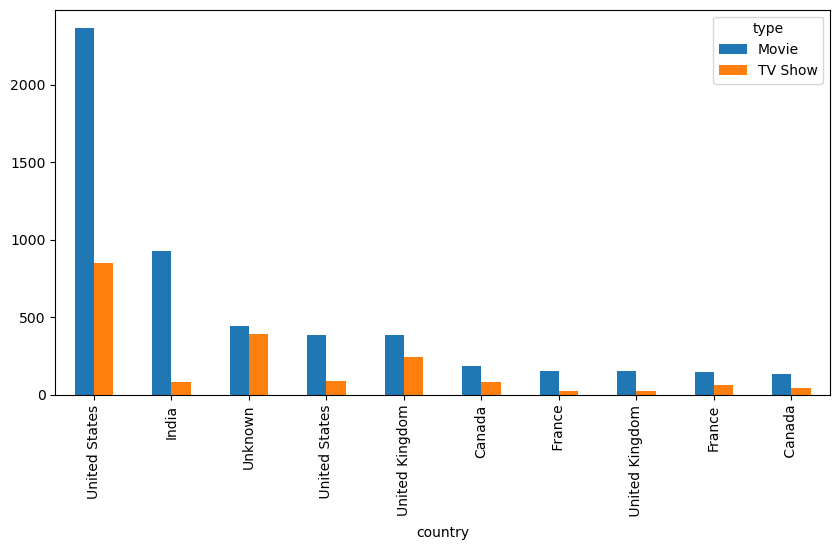

In [30]:
# Now that we have filtered only the top 20 countries based on content we can do the analysis further

country_content.head(10).plot(kind = 'bar',figsize = [10,5])

In [31]:
# Checking the trend of movie vs tv shows released over the past 30 years 

movies_shows = df_country[df_country['release_year'] >= (df_country['release_year'].max() - 30)]

In [32]:
movies_shows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


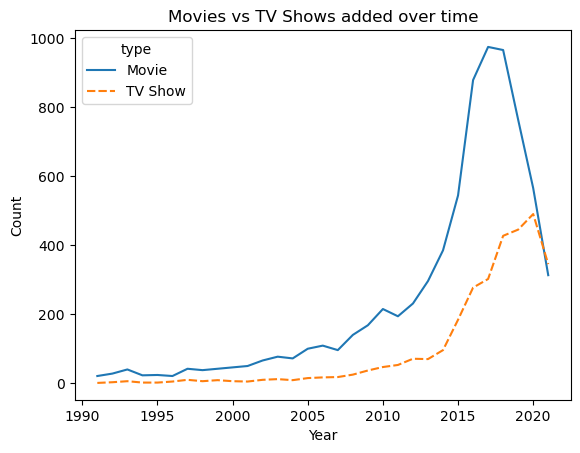

In [33]:
sns.lineplot(data= movies_shows.groupby(['release_year','type']).size().unstack(fill_value=0))
plt.title('Movies vs TV Shows added over time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

- There is a significant growth in the number of movies and tv shows released in the time of 2018-2019.
- Post 2019 we can see a very significant decline in the number of tv shows and movies released.
- The significant decline could be due to the Covid Pandemic.
- The number of movies have seen a significant rise during the years 2015-2019.
- The TV shows also show a continuous increase since 2015.
- Between 2017 and 2020, the gap between movies and TV shows significantly narrows.


In [48]:
# Extracting month from date_added
tvshow_df['date_added'] = pd.to_datetime(tvshow_df['date_added'])
tvshow_df.loc[:, 'date_added'] = pd.to_datetime(tvshow_df['date_added'])

C:\Users\nikhi\AppData\Local\Temp\ipykernel_17356\1755363602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tvshow_df['date_added'] = pd.to_datetime(tvshow_df['date_added'])


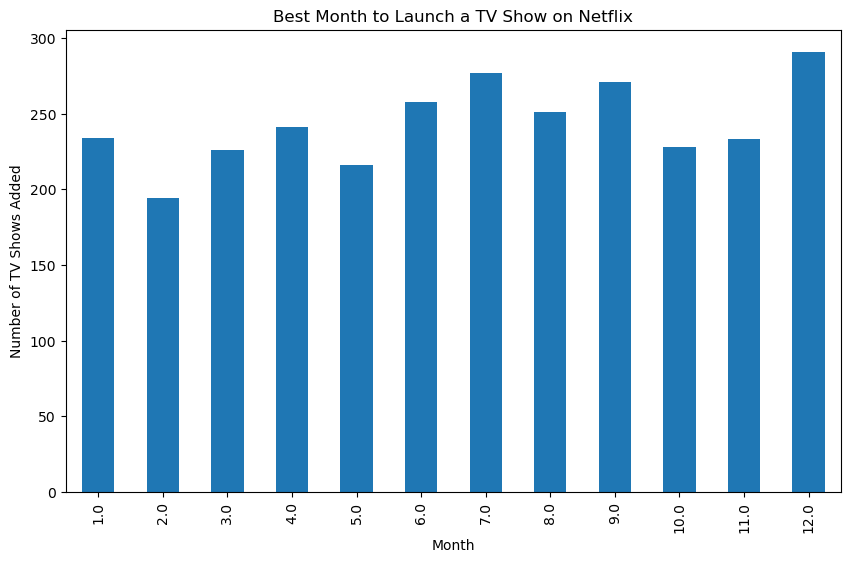

In [49]:
plt.figure(figsize=(10,6))
tvshow_df['month_added'].value_counts().sort_index().plot(kind='bar')

plt.title("Best Month to Launch a TV Show on Netflix")
plt.xlabel("Month")
plt.ylabel("Number of TV Shows Added")
plt.show()

- As per the graph the best time to release a tv show on Netflix is the month of December. So if we want to release any blockbuster shows we can definitely target the month of **December** for better viewing numbers.`
- The month of February and May have the less number of shows released. This gives us an opportunity to launch shows because lesser number of new shows added would mean lesser competition.
- The month of July also sees a higher surge in the number of shows released. So we can also target this month for some lighter releases which people would love to binge watch.
